In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.utils import resample
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

In [ ]:
file_path="/content/Data - Machine Learning - V2 (1).xlsx"
excel_file = pd.ExcelFile(file_path)
sheet_names = excel_file.sheet_names
print(sheet_names)
df = pd.read_excel(file_path, sheet_name=sheet_names[0])

['Student', 'Enrollment', 'Instructor', 'Sheet1', 'Course', 'Prerequisite', 'Department', 'Course_Department', 'Course_Offering']


In [ ]:
df_course = pd.read_excel(file_path, sheet_name='Course')
df_course_offering = pd.read_excel(file_path, sheet_name='Course_Offering')
df_enrollment = pd.read_excel(file_path, sheet_name='Enrollment')
course_cols = df_course[['Course_ID', 'Credit_Hours']]
course_offering_cols = df_course_offering[['Offering_ID', 'Course_ID', 'Semester', 'Instructor_ID', 'Year']]
enrollment_cols = df_enrollment[['Enrollment_ID', 'Offering_ID', 'Student_ID', 'Attendance','Coursework_Grade', 'Final_Grade']]
merged_enrollment_offering = pd.merge(enrollment_cols, course_offering_cols, on='Offering_ID', how='left')
final_combined_df = pd.merge(merged_enrollment_offering, course_cols, on='Course_ID', how='left')
df = final_combined_df[['Coursework_Grade', 'Attendance','Final_Grade']]
print("Combined DataFrame with requested columns and one-hot encoding:")
display(df.head())
print(f"\nShape of the combined DataFrame: {df.shape}")
print(f"\nInformation about the combined DataFrame:")
df.info()

Combined DataFrame with requested columns and one-hot encoding:


,Coursework_Grade,Attendance,Final_Grade
0,26.42,9,61.47
1,34.42,14,84.46
2,28.46,12,72.78
3,25.62,11,71.45
4,16.92,6,36.36



Shape of the combined DataFrame: (26938, 3)

Information about the combined DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26938 entries, 0 to 26937
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Coursework_Grade  26938 non-null  float64
 1   Attendance        26938 non-null  int64  
 2   Final_Grade       26938 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 631.5 KB


Correlation Matrix:


,Coursework_Grade,Attendance,Final_Grade
Coursework_Grade,1.000000,0.930866,0.977518
Attendance,0.930866,1.000000,0.931401
Final_Grade,0.977518,0.931401,1.000000


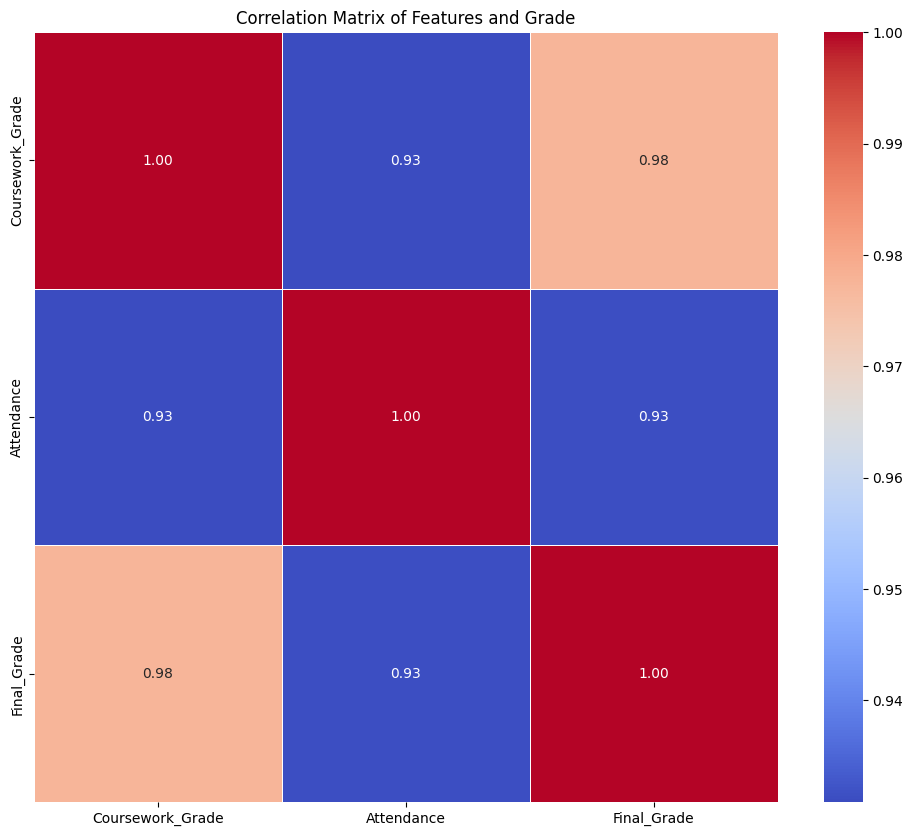

In [ ]:
correlation_matrix = df.corr()
print("Correlation Matrix:")
display(correlation_matrix)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features and Grade')
plt.show()

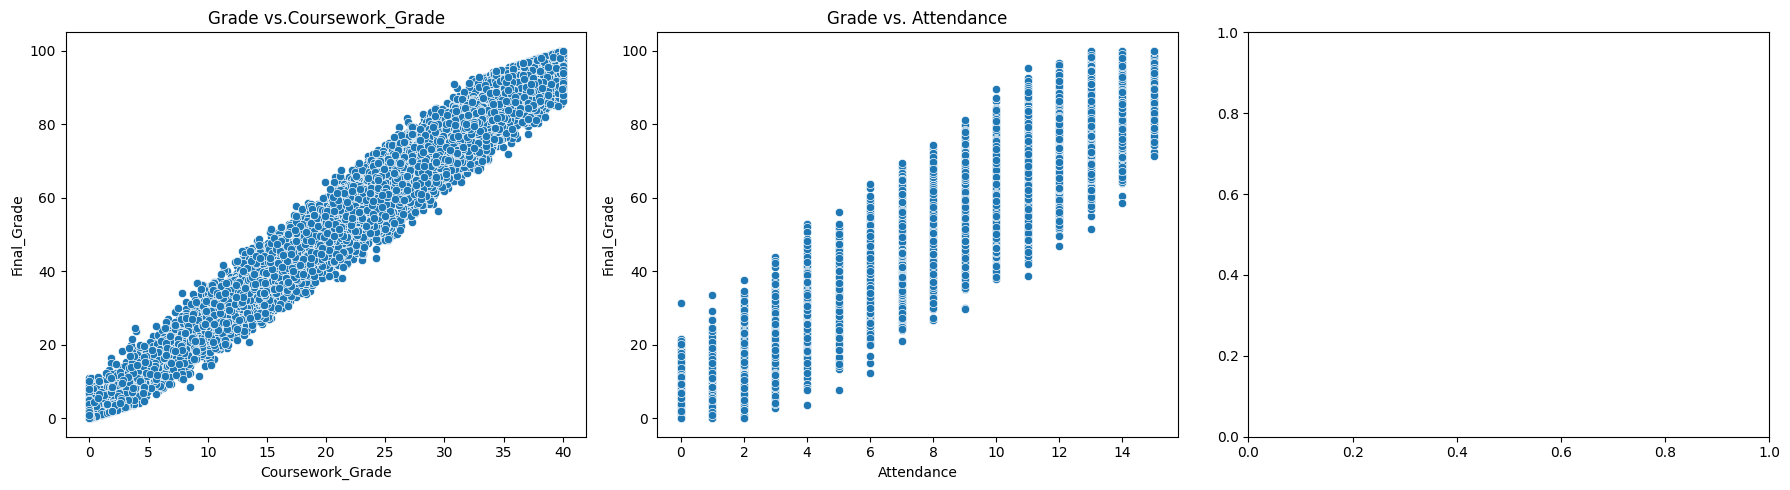

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x='Coursework_Grade', y='Final_Grade', data=df, ax=axes[0])
axes[0].set_title('Grade vs.Coursework_Grade')

sns.scatterplot(x='Attendance', y='Final_Grade', data=df, ax=axes[1])
axes[1].set_title('Grade vs. Attendance')

plt.tight_layout()
plt.show()

In [ ]:
X = df.drop('Final_Grade', axis=1)
y = df['Final_Grade']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (21550, 2)
Shape of X_test: (5388, 2)
Shape of y_train: (21550,)
Shape of y_test: (5388,)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
residuals = y_test - y_pred
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 3.21
Mean Squared Error (MSE): 16.03
Root Mean Squared Error (RMSE): 4.00
R-squared (R2): 0.96


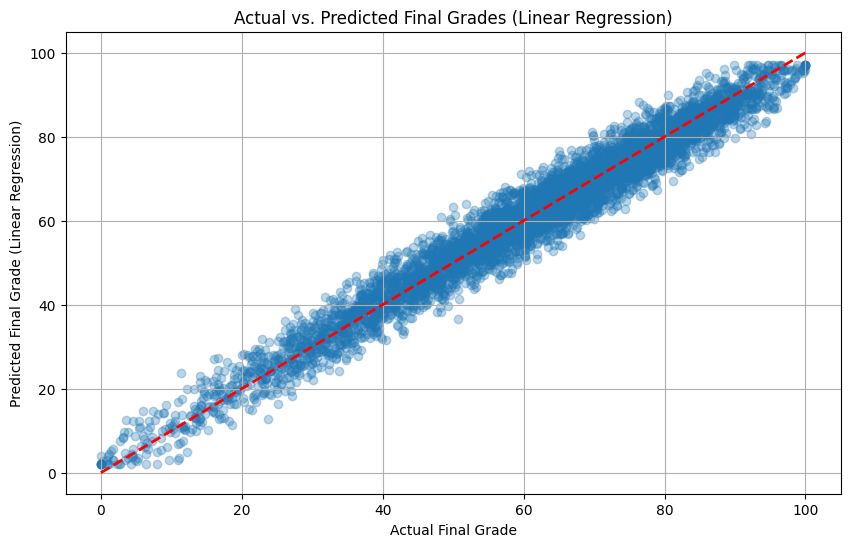

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Final Grade')
plt.ylabel('Predicted Final Grade (Linear Regression)')
plt.title('Actual vs. Predicted Final Grades (Linear Regression)')
plt.grid(True)
plt.show()

In [ ]:
std_dev_residuals = np.std(residuals)
z_score_95 = 1.96
margin_of_error = z_score_95 * std_dev_residuals
lower_bound_normal = y_pred - margin_of_error
upper_bound_normal = y_pred + margin_of_error
print(f"Standard deviation of training residuals: {std_dev_residuals:.2f}")
print(f"Margin of error for 95% PI: {margin_of_error:.2f}")

Standard deviation of training residuals: 4.00
Margin of error for 95% PI: 7.85


In [ ]:
prediction_intervals_normal = pd.DataFrame({
    'Actual_Final_Grade': y_test,
    'Predicted_Final_Grade': y_pred,
    'Lower_Bound_Normal_PI': lower_bound_normal,
    'Upper_Bound_Normal_PI': upper_bound_normal
})

print("Sample Prediction Intervals (95% assuming Normal Residuals):")
display(prediction_intervals_normal.sample(10))

Sample Prediction Intervals (95% assuming Normal Residuals):


,Actual_Final_Grade,Predicted_Final_Grade,Lower_Bound_Normal_PI,Upper_Bound_Normal_PI
12973,53.16,50.661208,42.812936,58.509479
1412,63.69,58.945012,51.096740,66.793283
17012,56.78,61.855355,54.007083,69.703626
19251,64.94,63.207193,55.358921,71.055464
13249,71.19,68.774156,60.925884,76.622427
1869,62.93,66.840184,58.991913,74.688456
18179,44.15,48.774292,40.926020,56.622563
25123,70.86,71.283027,63.434756,79.131299
25178,66.47,67.248564,59.400293,75.096836
2213,94.59,96.000182,88.151911,103.848454


In [ ]:
within_range_normal = (
    prediction_intervals_normal['Actual_Final_Grade'] >= prediction_intervals_normal['Lower_Bound_Normal_PI']
) & (
    prediction_intervals_normal['Actual_Final_Grade'] <= prediction_intervals_normal['Upper_Bound_Normal_PI']
)

percentage_within_range_normal = within_range_normal.mean() * 100

print(f"\nPercentage of actual grades falling within the 95% Frequentist Prediction Interval (assuming normal residuals): {percentage_within_range_normal:.2f}%")


Percentage of actual grades falling within the 95% Frequentist Prediction Interval (assuming normal residuals): 94.88%


In [ ]:
import pickle
from google.colab import files
with open('grade_model.pkl', 'wb') as f:
    pickle.dump(model, f)

files.download('grade_model.pkl')

## model # 2

In [ ]:
all_sheets = pd.read_excel(file_path, sheet_name=None)
students     = all_sheets["Student"]
enrollments  = all_sheets["Enrollment"]
offerings    = all_sheets["Course_Offering"]
courses      = all_sheets["Course"]
prerequisites= all_sheets["Prerequisite"]
course_dept  = all_sheets["Course_Department"]


In [ ]:
merged = enrollments.merge(
    offerings[["Offering_ID", "Course_ID", "Semester", "Year"]],
    on="Offering_ID",
    how="left"     )
merged = merged.merge(
    courses[["Course_ID", "Course_Title", "Course_Code", "Credit_Hours"]],
    on="Course_ID",
    how="left"
)
merged = merged.merge(
    students[["Student_ID", "Level", "Department_ID"]],
    on="Student_ID",
    how="left"
)

merged = merged.dropna(subset=["Course_ID"])


In [ ]:
train_data, test_data = train_test_split(enrollments, test_size=0.2, random_state=42)
offering_to_course = offerings.set_index('Offering_ID')['Course_ID'].to_dict()
train_user_item = train_data.pivot(index='Student_ID', columns='Offering_ID', values='Final_Grade')
train_user_item.columns = train_user_item.columns.map(offering_to_course)
train_user_item = train_user_item.groupby(axis=1, level=0).mean()
test_user_item = test_data.pivot(index='Student_ID', columns='Offering_ID', values='Final_Grade')
test_user_item.columns = test_user_item.columns.map(offering_to_course)
test_user_item = test_user_item.groupby(axis=1, level=0).mean()
student_means = train_user_item.mean(axis=1)
train_centered = train_user_item.sub(student_means, axis=0).fillna(0)
R_sparse = csr_matrix(train_centered.values)
k_factors = 50
U, sigma, Vt = svds(R_sparse, k=min(k_factors, R_sparse.shape[1]-1))
sigma_diag = np.diag(sigma)
predicted_ratings_array = np.dot(np.dot(U, sigma_diag), Vt)
svd_preds_df = pd.DataFrame(
    predicted_ratings_array + student_means.values.reshape(-1, 1),
    index=train_user_item.index,
    columns=train_user_item.columns
)
print("SVD Model Trained successfully.")

SVD Model Trained successfully.


/tmp/ipykernel_6059/2990079062.py:5: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  train_user_item = train_user_item.groupby(axis=1, level=0).mean()
/tmp/ipykernel_6059/2990079062.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  test_user_item = test_user_item.groupby(axis=1, level=0).mean()


In [ ]:
def get_svd_recommendations_filtered(student_id, preds_df, train_matrix, courses_df, prerequisites_df, enrollments_df, k=7):
    if student_id not in preds_df.index:
        return "Student ID not found in training data."
    scores = preds_df.loc[student_id]
    already_taken = train_matrix.loc[student_id].dropna().index.tolist()
    passed_courses = enrollments_df[(enrollments_df['Student_ID'] == student_id) & (enrollments_df['Final_Grade'] >= 50)]
    passed_course_ids = set(passed_courses.merge(offerings, on='Offering_ID')['Course_ID'])

    recommendations = []
    sorted_candidates = scores.sort_values(ascending=False)

    for cid, score in sorted_candidates.items():
        if cid in already_taken:
            continue
        reqs = prerequisites_df[prerequisites_df['Course_ID'] == cid]['Prerequisite_Course_ID'].tolist()
        if all(req_id in passed_course_ids for req_id in reqs):
            c_info = courses_df[courses_df['Course_ID'] == cid].iloc[0]
            results = {
                'Course_ID': cid,
                'Title': c_info['Course_Title'],
                'Code': c_info['Course_Code'],
                'Score': score
            }
            recommendations.append(results)

        if len(recommendations) == k:
            break

    return recommendations
test_sid = np.random.choice(svd_preds_df.index)
print(f"Generating {7} filtered recommendations for Student: {test_sid}")
filtered_recs = get_svd_recommendations_filtered(test_sid, svd_preds_df, train_user_item, courses, prerequisites, enrollments, k=7)
display(pd.DataFrame(filtered_recs))

Generating 7 filtered recommendations for Student: S0853


,Course_ID,Title,Code,Score
0,C59,STAT,208,72.269400
1,C71,STAT,418,68.852964
2,C58,STAT,205,67.446532
3,C65,STAT,314,66.518093
4,C69,STAT,412,65.625299
5,C56,STAT,203,64.298925
6,C26,COMP,401,63.939012


In [ ]:
def evaluate_svd_precision_filtered(preds_df, train_matrix, test_matrix, courses_df, prerequisites_df, enrollments_df, k=7):
    common_students = preds_df.index.intersection(test_matrix.index)
    precisions = []

    print(f"Evaluating {len(common_students)} students...")

    for sid in common_students:
        actual_test_courses = test_matrix.loc[sid].dropna().index.tolist()
        if not actual_test_courses:
            continue
        recommendations = get_svd_recommendations_filtered(
            sid, preds_df, train_matrix, courses_df, prerequisites_df, enrollments_df, k=k
        )
        if isinstance(recommendations, str):
            continue

        pred_ids = [r['Course_ID'] for r in recommendations]
        hits = len(set(pred_ids) & set(actual_test_courses))
        precisions.append(hits / k)
    return np.mean(precisions) * 100 if precisions else 0
accuracy_filtered = evaluate_svd_precision_filtered(
    svd_preds_df, train_user_item, test_user_item, courses, prerequisites, enrollments, k=7
)

print(f"\n--- Final Evaluation Result ---")
print(f"Filtered SVD Precision7: {accuracy_filtered:.2f}%")

Evaluating 980 students...

--- Final Evaluation Result ---
Filtered SVD Precision7: 13.78%


model # 3

In [ ]:
import pickle
with open('gpa_model.pkl', 'wb') as f:
   pickle.dump(gpa_model, f)
with open('gpa_features.pkl', 'wb') as f:
   pickle.dump(features, f)
print("Successfully saved 'gpa_model.pkl' and 'gpa_features.pkl'")

In [ ]:
n_students = 500
np.random.seed(42)
gpa_y1 = np.random.uniform(1.0, 4.0, n_students)
gpa_y2 = np.clip(gpa_y1 + np.random.normal(0, 0.5, n_students), 2.0, 4.0)
gpa_y3 = np.clip(gpa_y2 + np.random.normal(0, 0.4, n_students), 2.0, 4.0)
trend = gpa_y3 - gpa_y2
final_gpa = (0.1 * gpa_y1 + 0.2 * gpa_y2 + 0.7 * gpa_y3) + np.random.normal(0, 0.2, n_students)
final_gpa = np.clip(final_gpa, 2.0, 4.0)
df = pd.DataFrame({
    'Student_ID': range(1001, 1001 + n_students),
    'GPA_Year1': np.round(gpa_y1, 2),
    'GPA_Year2': np.round(gpa_y2, 2),
    'GPA_Year3': np.round(gpa_y3, 2),
    'Trend_Y3_Y2': np.round(trend, 2),
    'Final_GPA_Target': np.round(final_gpa, 2)
})

print(df.head())

   Student_ID  GPA_Year1  GPA_Year2  GPA_Year3  Trend_Y3_Y2  Final_GPA_Target
0        1001       2.12       2.29       2.53         0.23              2.70
1        1002       3.85       4.00       3.86        -0.14              4.00
2        1003       3.20       3.67       3.91         0.24              3.80
3        1004       2.80       2.51       2.95         0.44              2.70
4        1005       1.47       2.00       2.33         0.33              2.27


In [ ]:
output_file_name = 'GPA.xlsx'
df.to_excel(output_file_name, index=False)

from google.colab import files
files.download(output_file_name)
print(f"تم حفظ وتنزيل الملف: {output_file_name}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

تم حفظ وتنزيل الملف: GPA.xlsx


In [ ]:
X1 = df[['GPA_Year1']]
y = df['Final_GPA_Target']

X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)


model1 = LinearRegression()
model1.fit(X1_train, y_train)

y1_pred = model1.predict(X1_test)
r2_1 = r2_score(y_test, y1_pred)
mae_1 = mean_absolute_error(y_test, y1_pred)
mse_1 = mean_squared_error(y_test, y1_pred)

print("--- نتائج النموذج الأول (GPA السنة الأولى فقط) ---")
print(f"R-squared: {r2_1:.4f}")
print(f"MAE: {mae_1:.4f}")
print(f"MSE: {mse_1:.4f}")

--- نتائج النموذج الأول (GPA السنة الأولى فقط) ---
R-squared: 0.6039
MAE: 0.3535
MSE: 0.1954


In [ ]:
import pickle
from google.colab import files
with open('model1.pkl', 'wb') as f:
    pickle.dump(model1, f)
files.download('model1.pkl')
print("تم حفظ وتنزيل 'model1.pkl'")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

تم حفظ وتنزيل 'model1.pkl'


In [ ]:
X2 = df[['GPA_Year1', 'GPA_Year2']]
y = df['Final_GPA_Target']

X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)
model2 = LinearRegression()
model2.fit(X2_train, y_train)
y2_pred = model2.predict(X2_test)
r2_2 = r2_score(y_test, y2_pred)
mae_2 = mean_absolute_error(y_test, y2_pred)
mse_2 = mean_squared_error(y_test, y2_pred)

print("--- نتائج النموذج الثاني (GPA السنة الأولى والثانية) ---")
print(f"R-squared: {r2_2:.4f}")
print(f"MAE: {mae_2:.4f}")
print(f"MSE: {mse_2:.4f}")

--- نتائج النموذج الثاني (GPA السنة الأولى والثانية) ---
R-squared: 0.8738
MAE: 0.1922
MSE: 0.0622


In [ ]:
import pickle
from google.colab import files
with open('model2.pkl', 'wb') as f:
    pickle.dump(model2, f)
files.download('model2.pkl')
print("تم حفظ وتنزيل 'model2.pkl' ")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

تم حفظ وتنزيل 'model2.pkl' 


In [ ]:
X3 = df[['GPA_Year1', 'GPA_Year2', 'GPA_Year3']]
y = df['Final_GPA_Target']
X3_train, X3_test, y_train, y_test = train_test_split(X3, y, test_size=0.2, random_state=42)
model3 = LinearRegression()
model3.fit(X3_train, y_train)
y3_pred = model3.predict(X3_test)
r2_3 = r2_score(y_test, y3_pred)
mae_3 = mean_absolute_error(y_test, y3_pred)
mse_3 = mean_squared_error(y_test, y3_pred)
print("--- نتائج النموذج الثالث (GPA السنة الأولى والثانية والثالثة) ---")
print(f"R-squared: {r2_3:.4f}")
print(f"MAE: {mae_3:.4f}")
print(f"MSE: {mse_3:.4f}")

--- نتائج النموذج الثالث (GPA السنة الأولى والثانية والثالثة) ---
R-squared: 0.9404
MAE: 0.1327
MSE: 0.0294


In [ ]:
import pickle
from google.colab import files
with open('model3.pkl', 'wb') as f:
    pickle.dump(model3, f)
files.download('model3.pkl')
print("تم حفظ وتنزيل 'model3.pkl'.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

تم حفظ وتنزيل 'model3.pkl'.


In [ ]:
summary_df = pd.DataFrame({
    'Model': ['Model A(Year 1)', 'Model B (Year 1, 2)', 'Model C (Year 1, 2, 3)'],
    'R-squared': [r2_1, r2_2, r2_3],
    'MAE': [mae_1, mae_2, mae_3],
    'MSE': [mse_1, mse_2, mse_3]
})

display(summary_df)

,Model,R-squared,MAE,MSE
0,Model A(Year 1),0.603898,0.353502,0.195426
1,"Model B (Year 1, 2)",0.873828,0.192246,0.062250
2,"Model C (Year 1, 2, 3)",0.940391,0.132672,0.029409
